# Debugging Notebook for functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from mesh import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

1
Number of '7' in this set: 47, number of '1' in this set: 63


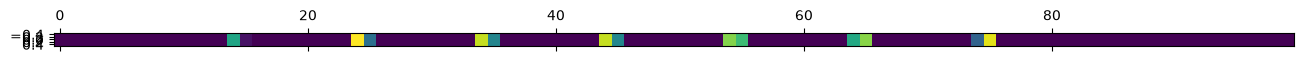

In [9]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 110 #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X, Y = get_data(values, mode, number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#Example of the first entry
plt.matshow(np.real(E_X[:,0]).reshape(1, -1)) #reshaping it just for plotting with plt.matshow
print(Y[0])

print("Number of '7' in this set: " + str(np.sum(Y == 7))+", number of '1' in this set: " + str(np.sum(Y == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

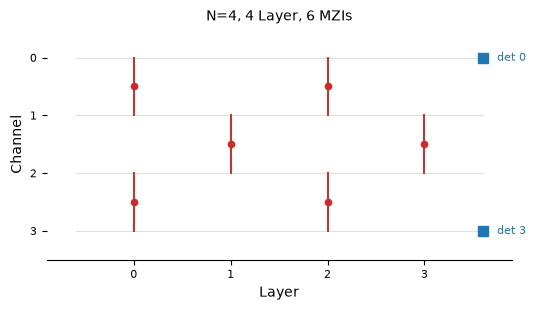

In [10]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)


plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)


# Initializing Mesh parameters
Functions in mesh.py, here just init_random, also init_haar already coded (later used)

Phis: [array([2.9756803 , 1.83079624]), array([2.52090954]), array([1.93396851, 2.03204352]), array([0.44527478])]
Thetas: [array([4.31061356, 5.62610221]), array([1.15876451]), array([5.83723495, 2.75939248]), array([3.50662814])]


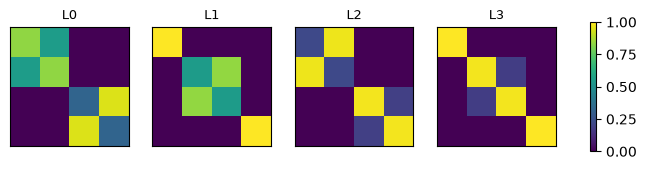

In [11]:
phis, thetas = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")

layers = test_mesh.layer_matrices(thetas, phis)   #building layers (transfer matrices) out of the parameters
fig, _ = plot_layers(layers, mode="Abs")


# Propagation

[[-0.04133156-0.02252978j -0.0514911 -0.01195099j -0.05766162-0.01479044j
  ... -0.04702676-0.01314721j -0.07095118-0.08216864j
  -0.04491525-0.01643029j]
 [ 0.09964834-0.02366519j  0.11157473+0.0087477j   0.066188  +0.02606868j
  ...  0.13558104+0.04223677j  0.12775493+0.01122517j
   0.10177145+0.00287478j]
 [ 0.04382931-0.00344058j  0.02295039+0.04593118j -0.01514108+0.04301881j
  ...  0.03011023+0.06473962j -0.04261671+0.01674915j
   0.01755032+0.04225833j]
 ...
 [-0.01884015+0.03935378j -0.01267794+0.01131294j  0.02943454-0.0343538j
  ... -0.26699689-0.3185362j  -0.03545828-0.17187624j
  -0.14639226-0.19008957j]
 [-0.00200439-0.03498504j  0.05555473+0.12413993j  0.0311785 +0.03747534j
  ... -0.30458124+0.09002087j -0.00066971+0.02241441j
  -0.18906766+0.01673559j]
 [ 0.0096858 -0.00679117j  0.0076438 -0.20688199j -0.0688496 -0.05320741j
  ...  0.00994387-0.12543838j -0.06385351+0.00080076j
   0.00408979-0.0066971j ]]
(100, 110)
[[[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.0

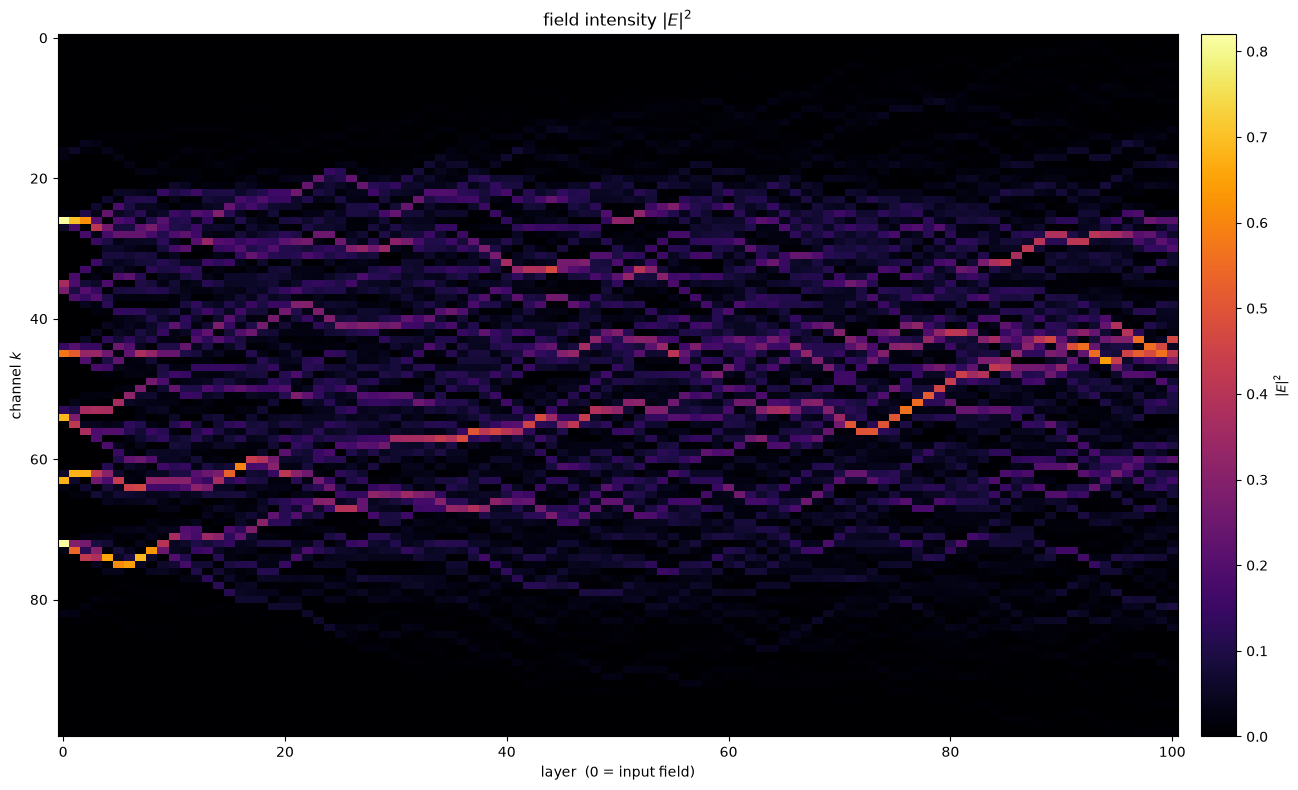

In [16]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters

E_out  = forward(E_X, layers)         #propagation that gives end result directly
print(E_out)                          #format: [channels, batches]
print(np.shape(E_out))

E_hist = forward_history(E_X, layers) #propagation that gives all E-fields for every layer
print(E_hist)                         #format: [layers, channels, batches]
I = np.abs(E_hist[:,:,2])**2
fig, _ = plot_intensity_map(I)